# Real vs. Euclidean distance — weighted mean golden ratio

Computes the ratio of real road-network distance to Euclidean distance for every Amazon delivery route (the full route, depot through all stops and
back), and reports a **single mean golden ratio** over all routes across all five metropolitan areas.

**Before running:**
1. Download the dataset — see `docs/DATA.md`.
2. Start one OSRM server per metro — see `docs/OSRM.md`.
3. Set `data_dir` in the loader cell below.

Run all cells top to bottom. The final cell prints the headline number.


## Step 1 — Load the data

Set `data_dir` to your local `model_build_inputs/` folder (see `docs/DATA.md`).
This cell builds `stops_df`, `routes_df`, `packages_df`, and `actual_sequences`,
and tags every stop with its metro via the station-code prefix. No edits needed
beyond the path.


In [7]:
# ============================================================
# STEP 1: DATA LOADER
# Defines: stops_df, routes_df, actual_sequences
# ============================================================
import os, json
import numpy as np
import pandas as pd

# --- Paths ---
data_dir = "./almrrc2021-data-training/model_build_inputs"  # <-- change to your local path
route_data_file       = os.path.join(data_dir, "route_data.json")
package_data_file     = os.path.join(data_dir, "package_data.json")
actual_sequences_file = os.path.join(data_dir, "actual_sequences.json")

# --- Load route + stop data ---
with open(route_data_file, "r") as f:
    route_data = json.load(f)

routes_list, stops_list = [], []
for route_id, rdata in route_data.items():
    routes_list.append({
        "route_id": route_id,
        "station_code": rdata["station_code"],
        "date": rdata["date_YYYY_MM_DD"],
        "departure_time_utc": rdata["departure_time_utc"],
        "executor_capacity_cm3": rdata["executor_capacity_cm3"],
        "route_score": rdata["route_score"],
    })
    for stop_id, sdata in rdata["stops"].items():
        stops_list.append({
            "route_id": route_id,
            "stop_id": stop_id,
            "lat": sdata["lat"],
            "lng": sdata["lng"],
            "type": sdata["type"],
            "zone_id": sdata["zone_id"],
        })

routes_df = pd.DataFrame(routes_list)
stops_df  = pd.DataFrame(stops_list)
print(f"Routes: {routes_df.shape}, Stops: {stops_df.shape}")

# --- Load package data (optional; kept for parity with your workflow) ---
with open(package_data_file, "r") as f:
    package_data = json.load(f)
packages_list = []
for route_id, stops in package_data.items():
    for stop_id, pkgs in stops.items():
        for pkg_id, pdata in pkgs.items():
            dim = pdata.get("dimensions", {})
            tw  = pdata.get("time_window", {})
            packages_list.append({
                "route_id": route_id, "stop_id": stop_id, "package_id": pkg_id,
                "scan_status": pdata.get("scan_status"),
                "start_time_utc": tw.get("start_time_utc"),
                "end_time_utc": tw.get("end_time_utc"),
                "planned_service_time_seconds": pdata.get("planned_service_time_seconds"),
                "depth_cm": dim.get("depth_cm"), "height_cm": dim.get("height_cm"),
                "width_cm": dim.get("width_cm"),
            })
packages_df = pd.DataFrame(packages_list)
print(f"Packages: {packages_df.shape}")

# --- Load actual visit sequences ---
# ALMRRC stores order as actual_sequences[route_id]["actual"] = {stop_id: order_index}
with open(actual_sequences_file, "r") as f:
    actual_sequences = json.load(f)
print(f"Sequences: {len(actual_sequences)} routes")

# --- Metro assignment ---
# ALMRRC station codes carry the metro in their prefix; this is exact.
_STATION_PREFIX_TO_METRO = {
    "DSE": "Seattle", "DLA": "Los Angeles", "DAU": "Austin",
    "DCH": "Chicago", "DBO": "Boston",
}
# Map each route -> metro via its station_code prefix
_route_to_metro = {
    r.route_id: _STATION_PREFIX_TO_METRO.get(str(r.station_code)[:3])
    for r in routes_df.itertuples()
}
stops_df["area"] = stops_df["route_id"].map(_route_to_metro)
print("Metros:", stops_df["area"].value_counts().to_dict())


Routes: (6112, 6), Stops: (904527, 6)
Packages: (1457175, 10)
Sequences: 6112 routes
Metros: {'Los Angeles': 414440, 'Chicago': 162410, 'Seattle': 155781, 'Boston': 140622, 'Austin': 31274}


## Step 2 — Configuration

Map each metro to the port its OSRM server is running on. If you run one server at
a time on port 5000, set every value to 5000 and the script will process whichever
metro is currently served (others will be skipped with a message).


In [8]:
OSRM_PORTS = {
    "Seattle": 5001,
    "Los Angeles": 5002,
    "Chicago": 5003,
    "Boston": 5004,
    "Austin": 5005,
}

PATH_BATCH = 90  # coords per OSRM /route call (stays under URL limits)


## Step 3 — Distance helpers

In [9]:
import numpy as np
import pandas as pd
import requests

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def eucl_km(df):
    """Straight-line length along ordered stops."""
    if len(df) < 2:
        return 0.0
    lat, lng = df["lat"].to_numpy(), df["lng"].to_numpy()
    return haversine_km(lat[:-1], lng[:-1], lat[1:], lng[1:]).sum()

def osrm_km(df, base_url):
    """Real road length along ordered stops, via a local OSRM server.
    Long paths are chunked with a one-point overlap so no leg is dropped."""
    pts = list(zip(df["lat"].to_numpy(), df["lng"].to_numpy()))
    if len(pts) < 2:
        return 0.0
    total, i = 0.0, 0
    while i < len(pts) - 1:
        chunk = pts[i:i + PATH_BATCH]
        if len(chunk) < 2:
            break
        coord_str = ";".join(f"{lng},{lat}" for lat, lng in chunk)
        r = requests.get(f"{base_url}/route/v1/driving/{coord_str}",
                         params={"overview": "false", "continue_straight": "true"},
                         timeout=60)
        r.raise_for_status()
        d = r.json()
        if d.get("code") != "Ok":
            raise RuntimeError(d.get("code"))
        total += d["routes"][0]["distance"] / 1000
        i += PATH_BATCH - 1
    return total

def closed_tour(depot, stops):
    """The full route: depot -> all stops -> depot."""
    if len(depot):
        return pd.concat([depot.iloc[[0]], stops, depot.iloc[[0]]], ignore_index=True)
    return pd.concat([stops, stops.iloc[[0]]], ignore_index=True)

def server_up(base_url):
    try:
        requests.get(f"{base_url}/route/v1/driving/-122.33,47.60;-122.34,47.61",
                     params={"overview": "false"}, timeout=5)
        return True
    except Exception:
        return False


## Step 4 — Compute the golden ratio for every route

For each metro whose OSRM server is up, this walks its routes, builds the ordered
stop sequence from `actual_sequences`, and computes Euclidean and real length for the full route
(depot through all stops and back). Progress prints every 50 routes as **it might take several minutes**.


In [11]:
import time

route_area = (stops_df.groupby("route_id")["area"]
              .agg(lambda s: s.value_counts().idxmax()))

records = []
for METRO, port in OSRM_PORTS.items():
    base_url = f"http://localhost:{port}"
    if not server_up(base_url):
        print(f"SKIP {METRO}: no OSRM server on {base_url}")
        continue

    metro_routes = [rid for rid in route_area[route_area == METRO].index
                    if rid in actual_sequences]
    print(f"{METRO}: {len(metro_routes)} routes (port {port})")

    t0, done = time.time(), 0
    for rid in metro_routes:
        try:
            order_map = actual_sequences[rid]["actual"]
            rs = stops_df[stops_df["route_id"] == rid].copy()
            rs["visit_order"] = rs["stop_id"].map(order_map)
            rs = (rs.dropna(subset=["visit_order"])
                    .sort_values("visit_order").reset_index(drop=True))
            if len(rs) < 2:
                continue

            is_depot = rs["type"].str.lower().eq("station")
            depot = rs[is_depot]
            deliv = rs[~is_depot].reset_index(drop=True)
            if len(deliv) < 2:
                continue

            # Full route: depot -> all stops -> depot
            tour = closed_tour(depot, deliv)
            eucl = eucl_km(tour)
            real = osrm_km(tour, base_url)
            if eucl <= 0:
                continue

            records.append({
                "route_id": rid, "metro": METRO, "n_stops": len(deliv),
                "golden_ratio": real / eucl,
            })
        except Exception as e:
            records.append({"route_id": rid, "metro": METRO, "n_stops": np.nan,
                            "golden_ratio": np.nan, "error": str(e)})
        done += 1
        if done % 50 == 0:
            print(f"   {done}/{len(metro_routes)}  ({time.time()-t0:.0f}s)")

results = pd.DataFrame(records)
results.to_csv("route_golden_ratios.csv", index=False)
ok = int(results["golden_ratio"].notna().sum())
print(f"\nComputed {ok} routes ({int(results['golden_ratio'].isna().sum())} failed). "
      f"Saved route_golden_ratios.csv")

Seattle: 1079 routes (port 5001)
   50/1079  (7s)
   100/1079  (11s)
   150/1079  (16s)
   200/1079  (21s)
   250/1079  (26s)
   300/1079  (31s)
   350/1079  (36s)
   400/1079  (41s)
   450/1079  (46s)
   500/1079  (51s)
   550/1079  (56s)
   600/1079  (61s)
   650/1079  (66s)
   700/1079  (70s)
   750/1079  (75s)
   800/1079  (79s)
   850/1079  (84s)
   900/1079  (89s)
   950/1079  (94s)
   1000/1079  (99s)
   1050/1079  (104s)
Los Angeles: 2888 routes (port 5002)
   50/2888  (10s)
   100/2888  (17s)
   150/2888  (23s)
   200/2888  (29s)
   250/2888  (34s)
   300/2888  (39s)
   350/2888  (44s)
   400/2888  (49s)
   450/2888  (55s)
   500/2888  (60s)
   550/2888  (65s)
   600/2888  (70s)
   650/2888  (75s)
   700/2888  (80s)
   750/2888  (84s)
   800/2888  (89s)
   850/2888  (94s)
   900/2888  (99s)
   950/2888  (104s)
   1000/2888  (109s)
   1050/2888  (114s)
   1100/2888  (119s)
   1150/2888  (124s)
   1200/2888  (129s)
   1250/2888  (133s)
   1300/2888  (138s)
   1350/2888  (143s)
 

## Step 5 — The ratio!

The mean golden ratio over all routes, all metros.

In [13]:
d = results[["golden_ratio", "metro"]].dropna()
d = d[(d["golden_ratio"] > 1.0) & (d["golden_ratio"] < 3.0)]   # physical range

# Pool all routes: each metro contributes in proportion to its number of routes.
vals = d["golden_ratio"].to_numpy()
mean_golden_ratio = vals.mean()

print(f"Routes included: {len(d)}")
print(f"Routes per metro: {d['metro'].value_counts().to_dict()}")
print()
print(f"  MEAN GOLDEN RATIO = {mean_golden_ratio:.2f}")
print()
print(f"  ≈ e^{np.log(mean_golden_ratio):.2f}")
print()
print(f"  ≈ ϕ = (1 + √5) / 2")




Routes included: 6103
Routes per metro: {'Los Angeles': 2880, 'Seattle': 1079, 'Chicago': 1002, 'Boston': 928, 'Austin': 214}

  MEAN GOLDEN RATIO = 1.61

  ≈ e^0.48

  ≈ ϕ = (1 + √5) / 2


## Step 6 — Descriptive statistics

Summary of the golden ratio per metro and pooled over all routes.

In [14]:
# Descriptive statistics of the golden ratio, per metro and total
d = results[["golden_ratio", "metro"]].dropna()
d = d[(d["golden_ratio"] > 1.0) & (d["golden_ratio"] < 3.0)]   # physical range

def describe(s):
    return pd.Series({
        "n": s.size,
        "mean": s.mean(),
        "std": s.std(ddof=1),
        "min": s.min(),
        "p25": s.quantile(0.25),
        "median": s.median(),
        "p75": s.quantile(0.75),
        "max": s.max(),
        "skew": s.skew(),
    })

per_city = d.groupby("metro")["golden_ratio"].apply(describe).unstack()
# Order metros consistently, then append the pooled "All" row
order = ["Seattle", "Los Angeles", "Austin", "Chicago", "Boston"]
per_city = per_city.reindex([m for m in order if m in per_city.index])
total = describe(d["golden_ratio"]).to_frame().T
total.index = ["All"]

stats_table = pd.concat([per_city, total])
stats_table["n"] = stats_table["n"].astype(int)
stats_table = stats_table.round(3)
stats_table.to_csv("golden_ratio_descriptives.csv")
print("Golden ratio — descriptive statistics (per metro and pooled):")
stats_table

Golden ratio — descriptive statistics (per metro and pooled):


,n,mean,std,min,p25,median,p75,max,skew
Seattle,1079,1.574,0.170,1.268,1.438,1.546,1.689,2.464,0.870
Los Angeles,2880,1.624,0.154,1.263,1.515,1.607,1.716,2.597,0.769
Austin,214,1.583,0.161,1.311,1.463,1.546,1.678,2.211,1.148
Chicago,1002,1.599,0.119,1.257,1.515,1.587,1.677,2.238,0.427
Boston,928,1.633,0.165,1.010,1.538,1.615,1.698,2.753,2.086
All,6103,1.611,0.155,1.010,1.505,1.595,1.701,2.753,1.004


## Step 7 — Lognormal fit and QQ plots

Fits a lognormal to the golden ratio (pooled and per metro) and shows a QQ plot for
each. The golden ratio is bounded below at 1, so the lognormal is fit on
`log(golden_ratio - 1)`; a straight QQ line then indicates a good lognormal fit.

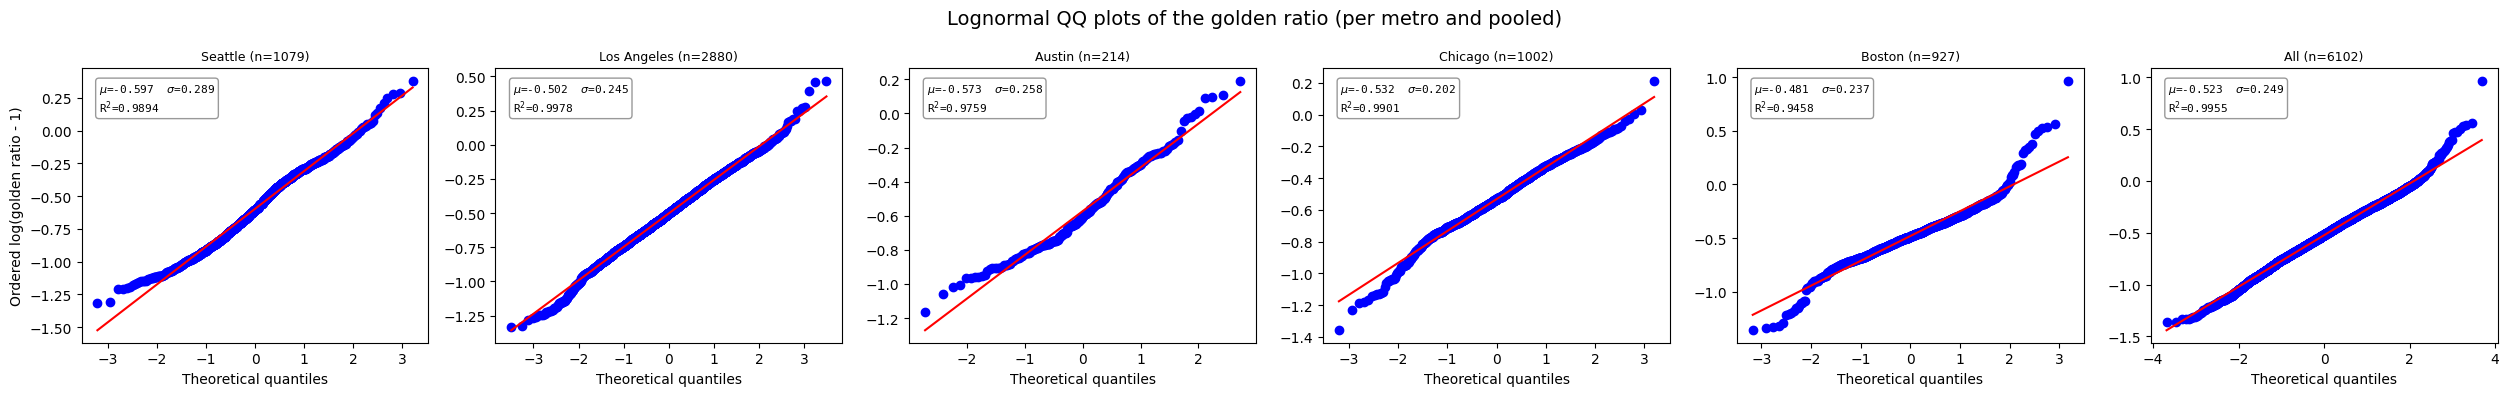

Lognormal fit parameters (log-space mu/sigma; mean in original units):


,group,n,mu,sigma,mean_golden_ratio,qq_r2
0,Seattle,1079,-0.5973,0.2890,1.5737,0.9894
1,Los Angeles,2880,-0.5019,0.2451,1.6238,0.9978
2,Austin,214,-0.5731,0.2575,1.5828,0.9759
3,Chicago,1002,-0.5320,0.2017,1.5995,0.9901
4,Boston,927,-0.4815,0.2374,1.6355,0.9458
5,All,6102,-0.5231,0.2494,1.6114,0.9955


In [20]:
import matplotlib.pyplot as plt
from scipy import stats
d = results[["golden_ratio", "metro"]].dropna()
d = d[(d["golden_ratio"] > 1.02) & (d["golden_ratio"] < 10.0)]
order = ["Seattle", "Los Angeles", "Austin", "Chicago", "Boston"]
present = [m for m in order if m in d["metro"].unique()]
# One panel per metro + one pooled "All" panel
panels = present + ["All"]
ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(4.2*ncols, 4))
if ncols == 1:
    axes = [axes]
fit_rows = []
for ax, name in zip(axes, panels):
    vals = (d["golden_ratio"] if name == "All"
            else d.loc[d["metro"] == name, "golden_ratio"]).to_numpy()
    if len(vals) < 20:
        ax.set_title(f"{name} (n={len(vals)})", fontsize=9)
        ax.text(0.5, 0.5, "too few", transform=ax.transAxes,
                ha="center", va="center", color="gray")
        continue
    # Lognormal fit: shift by the physical floor of 1, then work in log space
    logv = np.log(vals - 1.0)
    mu, sigma = logv.mean(), logv.std(ddof=1)          # underlying-normal params
    mean_gr = 1.0 + np.exp(mu + sigma**2 / 2)          # mean golden ratio (lognormal mean)
    # QQ against normal in log space (straight => lognormal in original space)
    _, (slope, intercept, r) = stats.probplot(logv, dist="norm", plot=ax)
    ax.set_title(f"{name} (n={len(vals)})", fontsize=9)
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Ordered log(golden ratio - 1)" if ax is axes[0] else "")
    ax.text(0.05, 0.95,
            r"$\mu$=" + f"{mu:.3f}  " + r"$\sigma$=" + f"{sigma:.3f}\n"
            + r"R$^2$=" + f"{r**2:.4f}",
            transform=ax.transAxes, va="top", fontsize=8, family="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))
    fit_rows.append({"group": name, "n": len(vals),
                     "mu": mu, "sigma": sigma,
                     "mean_golden_ratio": mean_gr, "qq_r2": r**2})
fig.suptitle("Lognormal QQ plots of the golden ratio (per metro and pooled)",
             fontsize=14)
plt.tight_layout()
plt.show()
fit_table = pd.DataFrame(fit_rows).round(4)
fit_table.to_csv("golden_ratio_lognormal_fits.csv", index=False)
print("Lognormal fit parameters (log-space mu/sigma; mean in original units):")
fit_table